# Problem

In [2]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import random
import torch
import pandas as pd
import sys
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from matplotlib.colors import LogNorm
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from IPython.display import Image, display

# This starts from the current working directory
# and goes up until it finds setup.py at the repository root
def find_root(current_path, marker="setup.py"):
    current_path = Path(current_path).resolve()
    for parent in [current_path] + list(current_path.parents):
        if (parent / marker).exists():
            return parent
    return current_path

PROJECT_ROOT = find_root(Path.cwd())
DATASETS_DIR = PROJECT_ROOT / "data" / "datasets"
RESULTS_DIR = PROJECT_ROOT / "data" / "results"
ASSETS_DIR = PROJECT_ROOT / "experiments" / "shared" / "assets"
print(f"Project root found at: {PROJECT_ROOT}")
DATASETS_DIR = PROJECT_ROOT / "data" / "datasets"
RESULTS_DIR = PROJECT_ROOT / "data" / "results"
ASSETS_DIR = PROJECT_ROOT / "experiments" / "shared" / "assets"

# Add project root to sys.path so we can import local packages
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))
# Now define the dataset path
DATASET_PATH = DATASETS_DIR / "20_to_100grid.csv"
MACRO_DATASET_PATH_100_20 = DATASET_PATH.parent / "100_to_20_macro.csv"
print(f"Loading dataset from: {DATASET_PATH}")

from rl_methods import LinearMDP, PolicySolver, EnvDataCollector
from rl_methods.fogas import (
    FOGASSolverVectorized,
    FOGASOracleSolverVectorized,
    FOGASHyperOptimizer,
    FOGASEvaluator,
    FOGASDataset,
)
from rl_methods.dataset_collection import DatasetAnalyzer
from rl_methods.fqi.fqi_solver import FQISolver
from rl_methods.fqi.fqi_evaluator import FQIEvaluator

seed = 44
np.random.seed(seed) # Add this
random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Project root found at: /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code
Loading dataset from: /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/datasets/20_to_100grid.csv
Using device: cpu


# Problem

### Scaling

In [2]:
def scale_grid(small_grid, factor=5):
    """
    Refine each coarse cell into a factor x factor block.
    Keep a single S and G at the scaled positions of the original ones.
    """
    large_grid = np.repeat(np.repeat(small_grid, factor, axis=0), factor, axis=1)

    # Find original S and G
    s_pos = np.argwhere(small_grid == 'S')[0]
    g_pos = np.argwhere(small_grid == 'G')[0]

    # Remove duplicated S/G blocks
    large_grid[large_grid == 'S'] = '.'
    large_grid[large_grid == 'G'] = '.'

    # Put one unique S/G at scaled coordinates
    s_big = tuple((s_pos * factor).tolist())
    g_big = tuple((g_pos * factor + (factor - 1)).tolist())  # choose bottom-right of block for G

    large_grid[s_big] = 'S'
    large_grid[g_big] = 'G'

    return large_grid

def scale_grid_goal_block(small_grid, factor=2):
    """
    Refine each coarse cell into a factor x factor block.
    Keep a single S, but expand G to the full factor x factor block.
    """
    large_grid = np.repeat(np.repeat(small_grid, factor, axis=0), factor, axis=1)

    s_pos = np.argwhere(small_grid == 'S')[0]
    g_pos = np.argwhere(small_grid == 'G')[0]

    # Remove duplicated start block only
    large_grid[large_grid == 'S'] = '.'

    # Reinsert one unique start at the top-left of the scaled start block
    s_big = tuple((s_pos * factor).tolist())
    large_grid[s_big] = 'S'

    # Expand the goal to the full fine block
    g_r, g_c = (g_pos * factor).tolist()
    large_grid[g_r:g_r + factor, g_c:g_c + factor] = 'G'

    return large_grid


### Path methods

In [3]:
def compute_optimal_path(mdp, mdp_data, size, max_steps=1000):
    """
    Computes the optimal path from start to goal by following mdp.pi_star 
    and looking up the resulting state in the transition matrix mdp.P.
    """
    current_state = mdp_data["start"]
    goal_state = mdp_data["goal"]
    pits = mdp_data["pits"]
    path = []
    
    for _ in range(max_steps):
        # Convert 1D state index back to 2D (row, col) coordinates
        r, c = divmod(current_state, size)
        path.append((r, c))
        
        # Stop condition: Reached the goal or fell into a pit
        if current_state == goal_state or current_state in pits:
            break
            
        # Extract the optimal action index from the pi_star vector at the current state
        best_a = torch.argmax(mdp.pi_star[current_state]).item()
        
        # Find the next state from the MDP transition matrix P
        # P has shape (N*A, N). The row index is: state * total_actions + action
        next_state = torch.argmax(mdp.P[current_state * mdp.A + best_a]).item()
        
        # Failsafe to prevent getting stuck in a loop against a wall
        if next_state == current_state:
            break
            
        current_state = next_state
        
    return path


def sample_policy_path(mdp, mdp_data, size, pi=None, max_steps=1000, rng=None):
    """
    Sample one trajectory from a policy pi.

    Args:
        mdp: PolicySolver / MDP object
        mdp_data: dict with keys 'start', 'goal', 'pits'
        size: grid side length
        pi: tensor of shape (N, A). If None, uses mdp.pi_star
        max_steps: safety limit
        rng: numpy random generator (optional)

    Returns:
        path: list of (row, col)
        states: list of visited state indices
        actions: list of sampled action indices
    """
    if pi is None:
        pi = mdp.pi_star

    if rng is None:
        rng = np.random.default_rng()

    current_state = mdp_data["start"]
    goal_state = mdp_data["goal"]
    pits = set(mdp_data["pits"])

    path = []
    states = []
    actions = []

    for _ in range(max_steps):
        r, c = divmod(current_state, size)
        path.append((r, c))
        states.append(current_state)

        if current_state == goal_state or current_state in pits:
            break

        action_probs = pi[current_state].detach().cpu().numpy()
        action_probs = action_probs / action_probs.sum()

        a = rng.choice(mdp.A, p=action_probs)
        actions.append(int(a))

        transition_probs = mdp.P[current_state * mdp.A + a].detach().cpu().numpy()
        next_state = rng.choice(mdp.N, p=transition_probs)

        if next_state == current_state:
            break

        current_state = int(next_state)

    return path, states, actions

def sample_multiple_policy_paths(mdp, mdp_data, size, pi=None, n_paths=20, max_steps=1000, seed=None):
    """
    Sample multiple trajectories from a policy.

    Returns:
        paths: list of paths, each path is a list of (row, col)
        states_list: list of state-index trajectories
        actions_list: list of action-index trajectories
    """
    rng = np.random.default_rng(seed)

    paths = []
    states_list = []
    actions_list = []

    for _ in range(n_paths):
        path, states, actions = sample_policy_path(
            mdp=mdp,
            mdp_data=mdp_data,
            size=size,
            pi=pi,
            max_steps=max_steps,
            rng=rng
        )
        paths.append(path)
        states_list.append(states)
        actions_list.append(actions)

    return paths, states_list, actions_list

def unique_paths(paths):
    """
    Remove duplicate paths while preserving order.

    Args:
        paths: list of paths, where each path is a list of (row, col)

    Returns:
        unique: list of unique paths
    """
    seen = set()
    unique = []

    for path in paths:
        key = tuple(path)
        if key not in seen:
            seen.add(key)
            unique.append(path)

    return unique

def sample_unique_policy_paths(mdp, mdp_data, size, pi=None, n_samples=200, max_unique=10, max_steps=1000, seed=None):
    """
    Sample many trajectories and keep up to max_unique distinct ones.
    """
    paths, _, _ = sample_multiple_policy_paths(
        mdp=mdp,
        mdp_data=mdp_data,
        size=size,
        pi=pi,
        n_paths=n_samples,
        max_steps=max_steps,
        seed=seed
    )

    uniq = unique_paths(paths)
    return uniq[:max_unique]

### Plotting methods

In [4]:
def plot_fogas_grid(grid_data):
    """
    Visualizes grids of any size (20x20, 50x50, 80x80, 100x100+) for RL analysis.
    Shows fine-grained cell divisions via grid lines, with tick density scaled
    adaptively so the plot is never cluttered.
    """
    size = grid_data.shape[0]

    # --- Mapping & Colors ---
    mapping = {'.': 0, '#': 1, 'P': 2, 'S': 3, 'G': 4}
    labels  = {0: 'Empty', 1: 'Wall', 2: 'Pit', 3: 'Start', 4: 'Goal'}
    numeric_grid = np.vectorize(mapping.get)(grid_data)

    colors = ['#F5F5F5', '#2C2C2C', '#E63946', '#457B9D', '#2DC653']
    cmap   = mcolors.ListedColormap(colors)

    # --- Adaptive figure size (cap at ~14 inches to stay readable) ---
    fig_size = min(14, max(6, size * 0.15))
    fig, ax  = plt.subplots(figsize=(fig_size, fig_size))

    ax.imshow(numeric_grid, cmap=cmap, vmin=0, vmax=4,
              interpolation='nearest', origin='upper')

    # --- Always draw every cell boundary ---
    #   imshow pixels are centred on integers, so edges sit at ±0.5
    ax.set_xticks(np.arange(-0.5, size, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, size, 1), minor=True)
    ax.grid(which='minor', color='#888888', linewidth=0.4, alpha=0.5)
    ax.tick_params(which='minor', bottom=False, left=False)   # hide minor tick marks

    # --- Major ticks for axis labels: adaptive spacing ---
    if size <= 20:
        major_step = 5
    elif size <= 50:
        major_step = 10
    elif size <= 80:
        major_step = 10
    else:  # 100+
        major_step = 20

    major_ticks = np.arange(0, size, major_step)
    ax.set_xticks(major_ticks)
    ax.set_yticks(major_ticks)
    ax.set_xticklabels(major_ticks, fontsize=8)
    ax.set_yticklabels(major_ticks, fontsize=8)
    
    # Restore readable integer labels on the axes
    ax.set_xticks(major_ticks)
    ax.set_yticks(major_ticks)
    ax.set_xticklabels(major_ticks, fontsize=8)
    ax.set_yticklabels(major_ticks, fontsize=8)

    ax.set_title(f"FOGAS Environment — {size}×{size} Grid", fontsize=14, pad=12)
    ax.set_xlabel("Column", fontsize=10)
    ax.set_ylabel("Row",    fontsize=10)

    # --- Legend ---
    patches = [
        mpatches.Patch(color=colors[i], label=f"{list(mapping.keys())[i]}  {labels[i]}")
        for i in range(len(colors))
    ]
    ax.legend(handles=patches, bbox_to_anchor=(1.02, 1), loc='upper left',
              borderaxespad=0., fontsize=9, framealpha=0.9)

    plt.tight_layout()
    plt.show()

def plot_agent_paths_with_labels(grid_data, paths, labels=None, title_suffix="", alpha=0.75):
    """
    Overlay trajectories on the grid using the new plot_fogas_grid style.
    """
    size = grid_data.shape[0]
    mapping = {'.': 0, '#': 1, 'P': 2, 'S': 3, 'G': 4}
    numeric_grid = np.vectorize(mapping.get)(grid_data)

    colors = ['#F5F5F5', '#2C2C2C', '#E63946', '#457B9D', '#2DC653']
    cmap = mcolors.ListedColormap(colors)

    # --- Adaptive figure size ---
    fig_size = min(14, max(6, size * 0.15))
    fig, ax = plt.subplots(figsize=(fig_size, fig_size))

    ax.imshow(numeric_grid, cmap=cmap, vmin=0, vmax=4,
              interpolation='nearest', origin='upper')

    # --- Thin cell boundary lines ---
    ax.set_xticks(np.arange(-0.5, size, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, size, 1), minor=True)
    ax.grid(which='minor', color='#888888', linewidth=0.4, alpha=0.5)
    ax.tick_params(which='minor', bottom=False, left=False)

    # --- Adaptive major tick labels ---
    if size <= 20:
        major_step = 5
    elif size <= 50:
        major_step = 10
    elif size <= 80:
        major_step = 10
    else:
        major_step = 20

    major_ticks = np.arange(0, size, major_step)
    ax.set_xticks(major_ticks)
    ax.set_yticks(major_ticks)
    ax.set_xticklabels(major_ticks, fontsize=8)
    ax.set_yticklabels(major_ticks, fontsize=8)

    # --- Overlay paths ---
    line_styles = ['-', '--', ':', '-.']
    path_colors = ['magenta', 'cyan', 'yellow', 'orange', 'lime', 'purple']

    for i, path in enumerate(paths):
        if not path:
            continue
        label = labels[i] if labels and i < len(labels) else f'Path {i+1}'
        rows, cols = zip(*path)
        ax.plot(cols, rows,
                label=label,
                color=path_colors[i % len(path_colors)],
                linestyle=line_styles[i % len(line_styles)],
                linewidth=2, marker='o', markersize=3, alpha=alpha)
        ax.scatter(cols[0],  rows[0],  marker='s', s=60, color=path_colors[i % len(path_colors)], zorder=5)
        ax.scatter(cols[-1], rows[-1], marker='*', s=120, color=path_colors[i % len(path_colors)], zorder=5)

    ax.set_title(f"FOGAS Path Comparison: {size}×{size} {title_suffix}", fontsize=14, pad=12)
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9, framealpha=0.9)

    plt.tight_layout()
    plt.show()

### GRID 

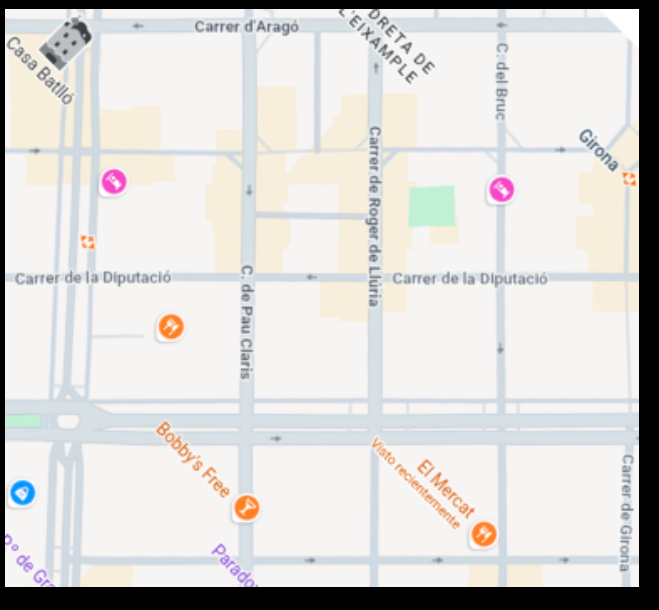

In [3]:
display(Image(filename=str(ASSETS_DIR / "grid_barcelona.png")))

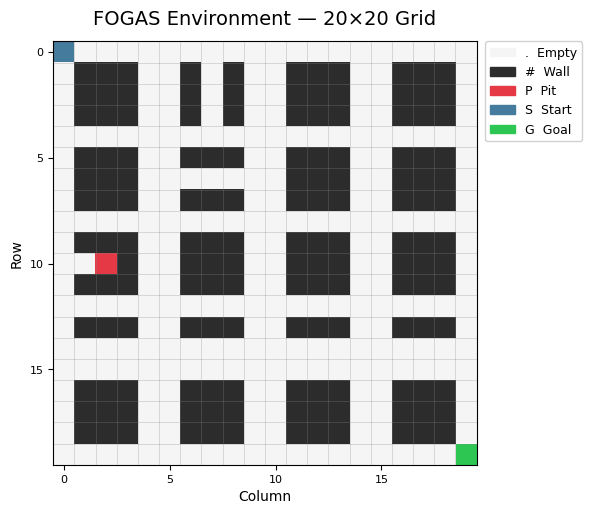

In [5]:
grid_layout = [
    "S...................",
    ".###..#.#..###..###.",
    ".###..#.#..###..###.",
    ".###..#.#..###..###.",
    "....................",
    ".###..###..###..###.",
    ".###.......###..###.",
    ".###..###..###..###.",
    "....................",
    ".###..###..###..###.",
    "..P#..###..###..###.",
    ".###..###..###..###.",
    "....................",
    ".###..###..###..###.",
    "....................",
    "....................",
    ".###..###..###..###.",
    ".###..###..###..###.",
    ".###..###..###..###.",
    "...................G"
]
# Load it as a 2D numpy array (how your environment expects it)
grid_20 = np.array([list(row) for row in grid_layout])
# To test it visually
plot_fogas_grid(grid_20)

# Linear MDP

In [ ]:
def generate_mdp_regular_grid(grid_data, gamma=0.99):
    size = grid_data.shape[0]
    N = size * size
    A = 4
    
    walls = set(np.where(grid_data.flatten() == '#')[0])
    pits = set(np.where(grid_data.flatten() == 'P')[0])
    goal = np.where(grid_data.flatten() == 'G')[0][0]
    start_node = np.where(grid_data.flatten() == 'S')[0][0]

    # --- Regular Grid Center Generation ---
    # Target 50% of the total states (N)
    target_num_centers = int(N * 0.5)─────────────────────────────────────────────────────────────────────────────
    
    # Because we are making a square meshgrid, we need the "centers per side"
    # which is the square root of the target number of centers.
    centers_per_side = int(np.sqrt(target_num_centers))
    
    # Creates a meshgrid in normalized [0, 1] space
    ticks = np.linspace(0.0, 1.0, centers_per_side)
    c_x, c_y = np.meshgrid(ticks, ticks)
    centers = torch.tensor(np.column_stack([c_x.ravel(), c_y.ravel()]), dtype=torch.float64)
    
    def reward_fn(x, a):
        x_int = int(x)
        if x_int == goal: return 10.0
        if x_int in pits: return -10.0
        return -0.01

    P = torch.zeros((N * A, N), dtype=torch.float64)
    for x in range(N):
        for a in range(A):
            if x in pits or x == goal:
                P[x * A + a, x] = 1.0
                continue
            r, c = divmod(x, size)
            if a == 0: r_n, c_n = max(0, r-1), c
            elif a == 1: r_n, c_n = min(size-1, r+1), c
            elif a == 2: r_n, c_n = r, max(0, c-1)
            elif a == 3: r_n, c_n = r, min(size-1, c+1)
            next_s = r_n * size + c_n
            if next_s in walls: next_s = x
            P[x * A + a, next_s] = 1.0

    return {
        "centers": centers, "walls": walls, "pits": pits, 
        "goal": goal, "start": start_node, "reward_fn": reward_fn, 
        "P": P, "N": N, "A": A, "gamma": gamma
    }

def get_phi_state_func(centers, sigma, size, pits, goal):
    """Returns a scale-invariant phi_state function."""
    def phi_state(x):
        # Normalize coordinates based on the current grid size
        r, c = divmod(int(x), size)
        coords = torch.tensor([r / (size - 1), c / (size - 1)], dtype=torch.float64)
        
        # Calculate RBF activations
        dist_sq = torch.sum((coords - centers)**2, dim=1)
        rbf = torch.exp(-dist_sq / (2 * sigma**2))
        
        # Indicator features as per FOGAS standard practice
        is_pit = 1.0 if int(x) in pits else 0.0
        is_goal = 1.0 if int(x) == goal else 0.0
        indicators = torch.tensor([is_pit, is_goal], dtype=torch.float64)
        
        # Feature vector includes RBFs, Bias (1.0), and Indicators
        return torch.cat([rbf, torch.ones(1, dtype=torch.float64), indicators])
    return phi_state

def calculate_local_sigma(centers, k=2):
    """Computes sigma based on k-nearest neighbors for spatial precision."""
    dist_matrix = torch.cdist(centers, centers, p=2)
    topk_dists, _ = torch.topk(dist_matrix, k + 1, largest=False, dim=1)
    return torch.mean(topk_dists[:, 1])

def plot_grid_with_centers(grid_data, centers):
    """
    Visualizes the grid with RBF feature centers overlaid,
    using the new plot_fogas_grid style.
    """
    size = grid_data.shape[0]
    mapping = {'.': 0, '#': 1, 'P': 2, 'S': 3, 'G': 4}
    numeric_grid = np.vectorize(mapping.get)(grid_data)

    colors = ['#F5F5F5', '#2C2C2C', '#E63946', '#457B9D', '#2DC653']
    cmap   = mcolors.ListedColormap(colors)

    # --- Adaptive figure size ---
    fig_size = min(14, max(6, size * 0.15))
    fig, ax  = plt.subplots(figsize=(fig_size, fig_size))

    ax.imshow(numeric_grid, cmap=cmap, vmin=0, vmax=4,
              interpolation='nearest', origin='upper')

    # --- Thin cell boundary lines ---
    ax.set_xticks(np.arange(-0.5, size, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, size, 1), minor=True)
    ax.grid(which='minor', color='#888888', linewidth=0.4, alpha=0.5)
    ax.tick_params(which='minor', bottom=False, left=False)

    # --- Adaptive major tick labels ---
    if size <= 20:
        major_step = 5
    elif size <= 80:
        major_step = 10
    else:
        major_step = 20

    major_ticks = np.arange(0, size, major_step)
    ax.set_xticks(major_ticks)
    ax.set_yticks(major_ticks)
    ax.set_xticklabels(major_ticks, fontsize=8)
    ax.set_yticklabels(major_ticks, fontsize=8)

    # --- Overlay RBF centers (scaled from [0,1] → [0, size-1]) ---
    centers_scaled = centers.numpy() * (size - 1)
    marker_size = max(20, min(80, 800 // size))   # shrink markers for large grids
    ax.scatter(centers_scaled[:, 1], centers_scaled[:, 0],
               c='deepskyblue', marker='x',
               s=marker_size, linewidths=0.8,
               label='RBF Feature Centers', alpha=0.8, zorder=5)

    ax.set_title(f"FOGAS Feature Allocation — {size}×{size} Grid", fontsize=14, pad=12)
    ax.legend(loc='upper right', fontsize=9, framealpha=0.9)

    plt.tight_layout()
    plt.show()

# 20x20

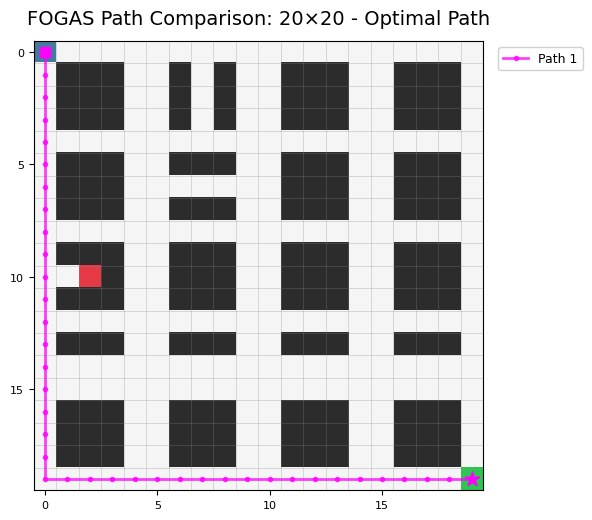

In [7]:
size = 20

# --- STEP 2: Generate MDP Components with Regular Grid ---
# We use 15 centers per side (225 total RBFs) for a 50x50 or 100x100 grid.
mdp_data = generate_mdp_regular_grid(grid_20)

# --- STEP 3: Calculate Scale-Invariant Sigma ---
# Using Local KNN Sigma (k=2) ensures RBFs overlap with neighbors
# but don't become "blurry" across walls.
centers = mdp_data["centers"]
rbf_sigma = calculate_local_sigma(centers, k=2)

# --- STEP 4: Define the Scale-Invariant Phi Functions ---
# Note: size is passed here to ensure normalization: r / (size-1)
phi_s = get_phi_state_func(
    centers, 
    rbf_sigma, 
    size, 
    mdp_data["pits"], 
    mdp_data["goal"]
)

def phi(x, a):
    """Coupled Feature Map: phi(x, a) = e_a ⊗ phi_state(x)"""
    s_feat = phi_s(x)
    A = 4
    e_a = torch.zeros(A, dtype=torch.float64)
    e_a[int(a)] = 1.0
    return torch.kron(e_a, s_feat)

# Calculate Feature Dimension d
sample_feat = phi(0, 0)
d = int(sample_feat.shape[0])

# --- STEP 5: Create the FOGAS Solver Object ---
# (Assumes your PolicySolver class is defined as in your previous code)
states = torch.arange(size * size, dtype=torch.int64)
actions = torch.arange(4, dtype=torch.int64)

mdp = PolicySolver(
    states=states, 
    actions=actions, 
    phi=phi,
    reward_fn=mdp_data["reward_fn"], 
    gamma=mdp_data["gamma"], 
    x0=mdp_data["start"], 
    P=mdp_data["P"]
)
optimal_path = compute_optimal_path(mdp, mdp_data, size=size)
# 2. Plot the trajectory
plot_agent_paths_with_labels(grid_20, [optimal_path], title_suffix="- Optimal Path")

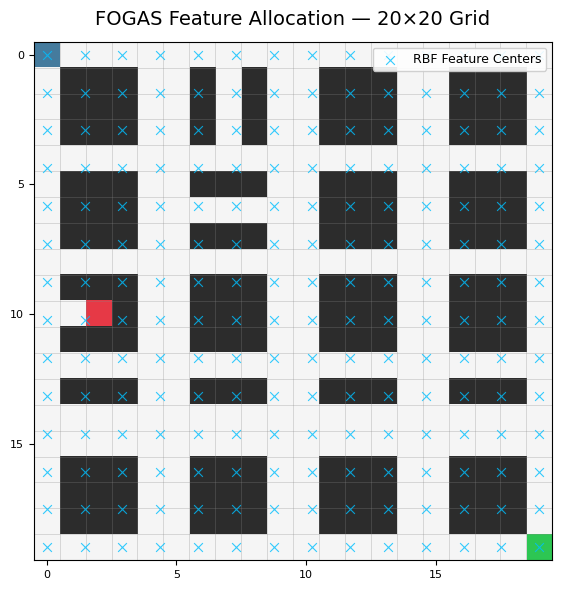

In [8]:
plot_grid_with_centers(grid_data=grid_20, centers=centers)

### Dataset creation

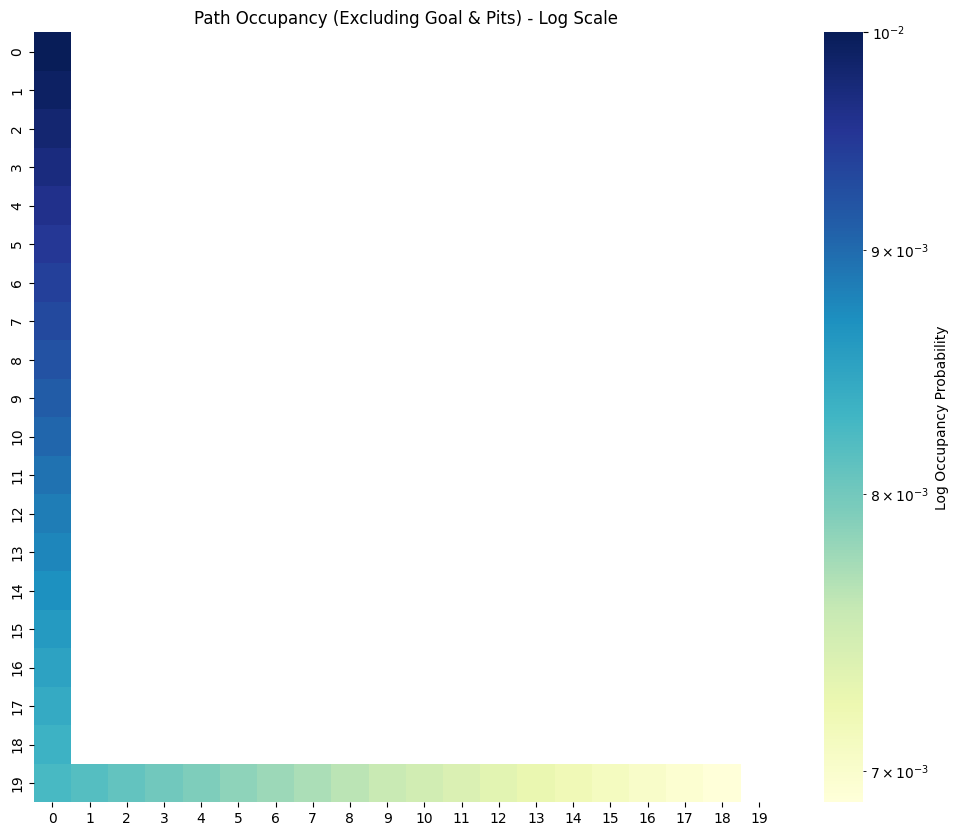

In [9]:
# 1. Get occupancy probabilities
probs = mdp.state_mu_star.detach().cpu().numpy().copy()

# 2. Mask the Goal/Pits (Terminal States) for better visual scaling
# The goal index is usually size*size - 1
terminal_indices = list(mdp_data['pits']) + [mdp_data['goal']]
for idx in terminal_indices:
    probs[idx] = 0.0

# 3. Reshape
grid_size = size
occupancy_grid = probs.reshape(grid_size, grid_size)

# 4. Plot with Log Normalization to see small probabilities along the path
plt.figure(figsize=(12, 10))
sns.heatmap(occupancy_grid, 
            cmap="YlGnBu", 
            norm=LogNorm(vmin=probs[probs>0].min() if any(probs>0) else 1e-6, vmax=probs.max()),
            cbar_kws={'label': 'Log Occupancy Probability'})

plt.title("Path Occupancy (Excluding Goal & Pits) - Log Scale")
plt.show()


In [10]:
reset_options = {
    'x0': 0.1, 
    'occupancy': 0.9
}

# Initialize the collector with these options
collector = EnvDataCollector(
    mdp=mdp,
    env_name="50grid",
    restricted_states=mdp_data["walls"],  # These will never be starting states
    reset_probs=reset_options,
    max_steps=100
)

# Create an epsilon-greedy pi_star (30% optimal, 70% random)
epsilon_policy = (mdp.pi_star, 0.3)

df = collector.collect_mixed_dataset_terminal_aware(
    policies=[epsilon_policy, "random"],  
    proportions=[0.8, 0.2],
    n_steps=20000,
    episode_based=True,                   
    save_path=str(DATASET_PATH),
    verbose=True,
    extra_steps=20 
)


  MIXED TERMINAL-AWARE DATASET COLLECTION SUMMARY (TORCH)
Total transitions: 20000
Total episodes: 326
Extra steps: 20

Policy Distribution:
  Policy 0: 14113 steps (70.6%) | Target: 80.0% | Episodes: 263
  Policy 1:  5887 steps (29.4%) | Target: 20.0% | Episodes: 64

✅ Mixed terminal-aware dataset saved to: /shared/home/mauro.diaz/work/FOGAS/datasets/20_to_100grid.csv


In [11]:
analyzer = DatasetAnalyzer(DATASET_PATH)

ratio = analyzer.feature_coverage_ratio(
    mdp=mdp,
    beta=1e-6,
    use_optimal_policy=True,
    verbose=True,
    return_details=True,
)


Feature Coverage Ratio Details
------------------------------
  Dataset size (n):         20000
  MDP dims (N, A, d):        (400, 4, 796)
  gamma:                    0.99
  beta (ridge):             1e-06
  policy source:            provided

  Occupancy μ_pi summary:
    sum:                    1
    min / max:              0 / 0.682555

  Feature occupancy λ_pi summary:
    ||λ||_2:                1.38166
    ||λ||_1:                5.13166
    max |λ_i|:              0.682555

  Empirical covariance Λ_n:
    diag min / mean / max:  1e-06 / 0.00463558 / 0.324551
    eig min / max:          1e-06 / 0.842824
    condition number:       842824

  Coverage ratio:           2.66782


Total states: 400
Walls: 148
Visited: 184
Non-visited non-walls: 68


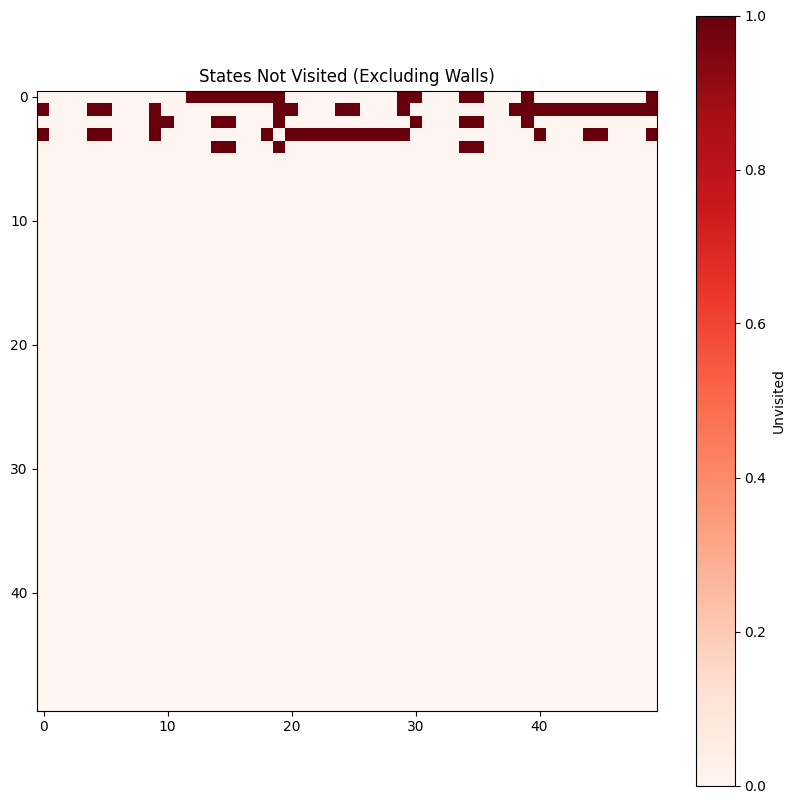

In [12]:
# 1. Get all visited states from your collected dataset
visited_states = set(df['state'].unique())

# 2. Get the set of wall states
# Since you are in the 50x50grid notebook, mdp_data contains the wall indices
wall_states = set(mdp_data['walls'])

# 3. Calculate states that were NOT visited and are NOT walls
all_states = set(range(mdp.N))
non_visited_non_walls = all_states - visited_states - wall_states

print(f"Total states: {mdp.N}")
print(f"Walls: {len(wall_states)}")
print(f"Visited: {len(visited_states)}")
print(f"Non-visited non-walls: {len(non_visited_non_walls)}")

# Optional: Convert indices to (row, col) coordinates for the 50x50 grid
size = 50
coords = [divmod(s, size) for s in sorted(list(non_visited_non_walls))]
# print(coords[:10]) # Show first 10 missing states

# Create an empty 50x50 map (0 = visited/wall, 1 = missing)
coverage_map = np.zeros((size, size))
for s in non_visited_non_walls:
    r, c = divmod(s, size)
    coverage_map[r, c] = 1
plt.figure(figsize=(10, 10))
plt.imshow(coverage_map, cmap='Reds')
plt.title("States Not Visited (Excluding Walls)")
plt.colorbar(label="Unvisited")
plt.show()


### Solving it

[FOGASSolverVectorized] omega estimated via regression (beta_omega=1.00e-07, n=20000)

     REWARD APPROXIMATION ANALYSIS
Metric                                Value
────────────────────────────────────────────
Max |error|                        0.073568
Mean |error|                       0.005549
RMSE                               0.010464
R² (explained variance)            0.999782


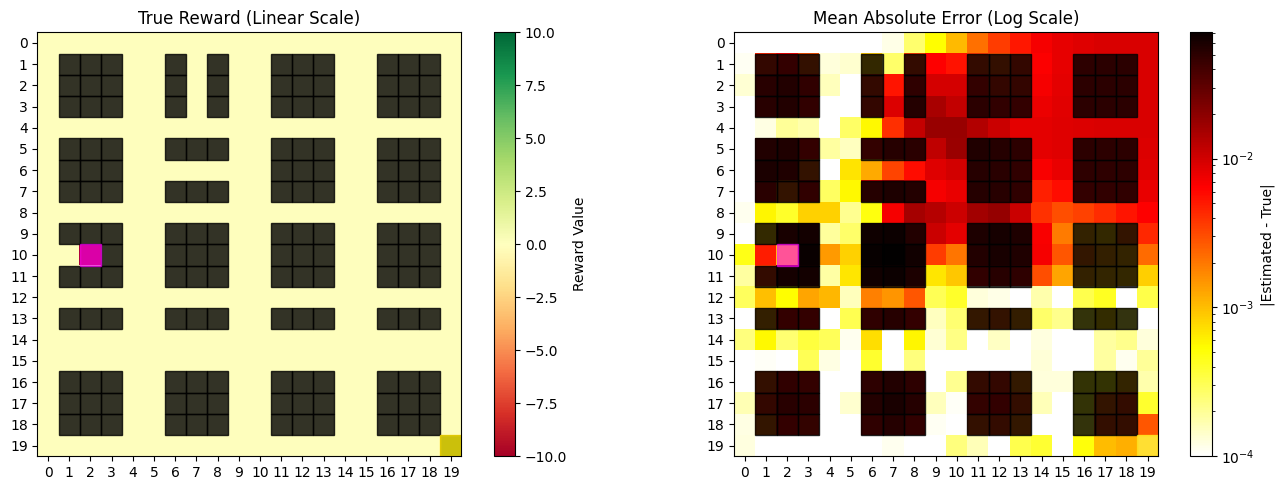

In [13]:
solver_e = FOGASSolverVectorized(
    mdp=mdp,
    csv_path=str(DATASET_PATH),
    device=device,
    beta=1e-7,
    seed=seed)
evaluator_e = FOGASEvaluator(solver_e)
optimizer_e = FOGASHyperOptimizer(solver=solver_e,metric_callable=evaluator_e.get_metric("reward"), seed=seed)

evaluator_e.analyze_reward_approximation(
    walls=mdp_data["walls"], 
    pits=mdp_data["pits"], 
    goal=mdp_data["goal"]
    )

In [14]:
# Run solver with best alpha and fixed rho, eta
solver_e.run(alpha=0.0001, eta=0.00002, rho=0.5, tqdm_print=True, T=25000)
evaluator_e.print_optimal_path(goal_state=mdp_data["goal"])

FOGAS: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 25000/25000 [00:46<00:00, 539.96it/s]



  OPTIMAL PATH VISUALIZATION - Learned Policy (π_FOGAS)

Initial State: 0
Goal State: 399
Discount Factor (γ): 0.99

----------------------------------------------------------------------

  Step   0 │ State: 0        │ Action: 1       │ Reward:  -0.010 │ → 20
  Step   1 │ State: 20       │ Action: 1       │ Reward:  -0.010 │ → 40
  Step   2 │ State: 40       │ Action: 1       │ Reward:  -0.010 │ → 60
  Step   3 │ State: 60       │ Action: 1       │ Reward:  -0.010 │ → 80
  Step   4 │ State: 80       │ Action: 1       │ Reward:  -0.010 │ → 100
  Step   5 │ State: 100      │ Action: 1       │ Reward:  -0.010 │ → 120
  Step   6 │ State: 120      │ Action: 1       │ Reward:  -0.010 │ → 140
  Step   7 │ State: 140      │ Action: 1       │ Reward:  -0.010 │ → 160
  Step   8 │ State: 160      │ Action: 1       │ Reward:  -0.010 │ → 180
  Step   9 │ State: 180      │ Action: 1       │ Reward:  -0.010 │ → 200
  Step  10 │ State: 200      │ Action: 1       │ Reward:  -0.010 │ → 220
  Step  11 

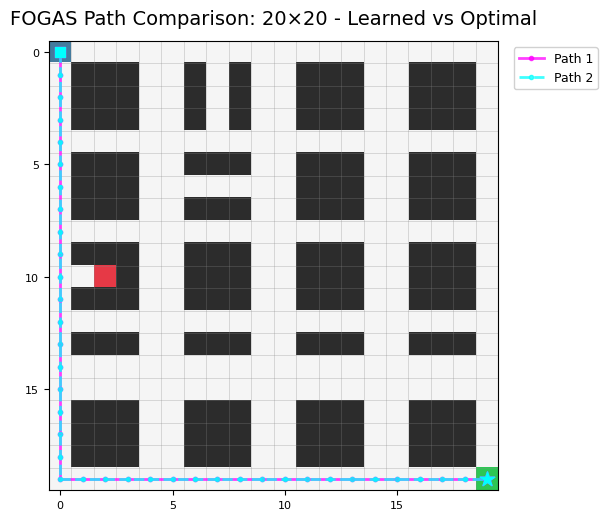

In [15]:
traj = evaluator_e.simulate_trajectory(goal_state=mdp_data["goal"], max_steps=38)
size = grid_20.shape[0]

# Extract 'state' from all steps + append the final 'next_state' to include the goal
path_coords = [divmod(step['state'], size) for step in traj]
if traj:
    path_coords.append(divmod(traj[-1]['next_state'], size))  # ← add the goal

traj_opt = evaluator_e.simulate_trajectory(pi=evaluator_e.mdp.pi_star, goal_state=mdp_data["goal"])
path_opt = [divmod(step['state'], size) for step in traj_opt]
if traj_opt:
    path_opt.append(divmod(traj_opt[-1]['next_state'], size))  # ← add the goal

plot_agent_paths_with_labels(grid_20, [path_coords, path_opt], title_suffix="- Learned vs Optimal")

# 100x100

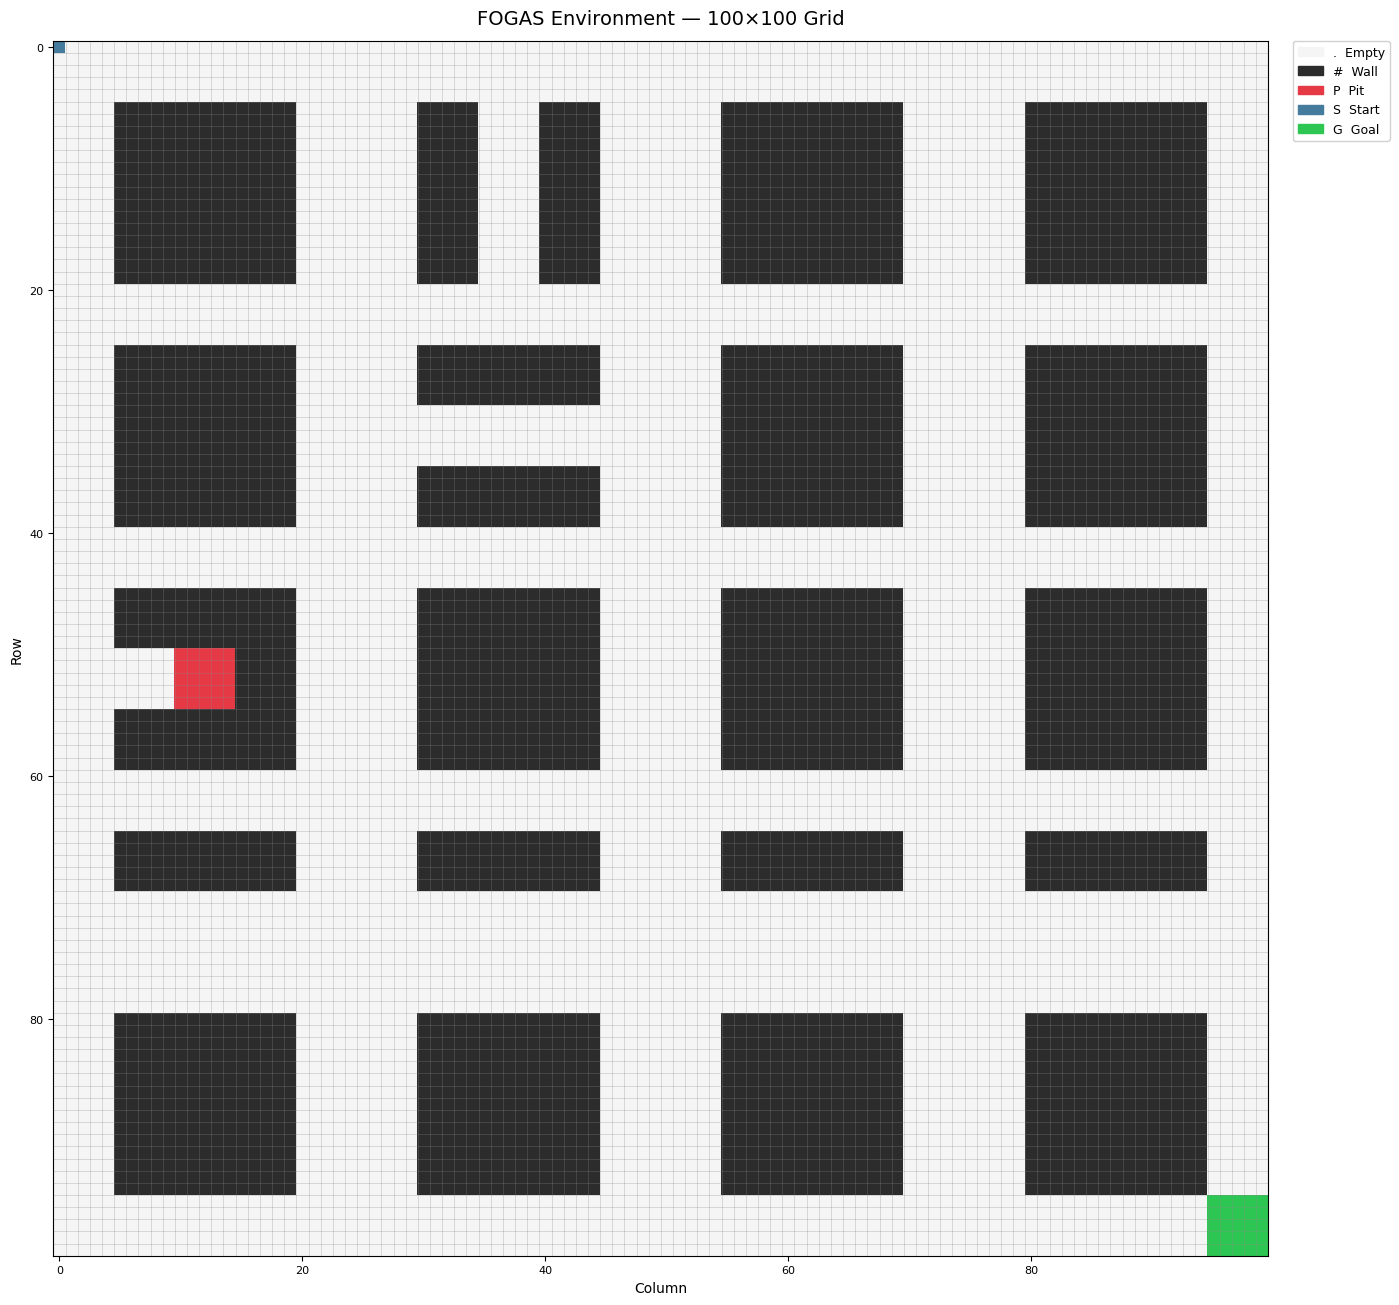

In [16]:
grid_100 = scale_grid_goal_block(grid_20, factor=5)
plot_fogas_grid(grid_100)

In [ ]:
# 1. Define base grid and scale it
grid_20  = np.array([list(row) for row in grid_layout])
grid_100 = scale_grid(grid_20, factor=5)
size_20, size_100 = grid_20.shape[0], grid_100.shape[0]

# 2. Generate MDP components 
mdp_data_20  = generate_mdp_regular_grid(grid_20)
mdp_data_100 = generate_mdp_regular_grid(grid_100, gamma=(mdp_data_20["gamma"] ** 5))

# 3. Extract the ground-truth feature space
fixed_centers = mdp_data_20["centers"]
fixed_sigma   = calculate_local_sigma(fixed_centers, k=2)

# 4. Explicitly redefine the 20x20 feature map to avoid stale closures
phi_s_20 = get_phi_state_func(fixed_centers, fixed_sigma, size_20, mdp_data_20["pits"], mdp_data_20["goal"])

def phi_20_fixed(x, a):
    s_feat = phi_s_20(x)
    e_a = torch.zeros(4, dtype=torch.float64)
    e_a[int(a)] = 1.0
    return torch.kron(e_a, s_feat)

# 5. Define the 100x100 feature map using the exact same centers
phi_s_100 = get_phi_state_func(fixed_centers, fixed_sigma, size_100, mdp_data_100["pits"], mdp_data_100["goal"])

def phi_100_fixed(x, a):
    s_feat = phi_s_100(x)
    e_a = torch.zeros(4, dtype=torch.float64)
    e_a[int(a)] = 1.0
    return torch.kron(e_a, s_feat)

# --- STEP 7: Create the FOGAS Solver Object for 100x100 ---
states_100  = torch.arange(size_100 * size_100, dtype=torch.int64)
actions_100 = torch.arange(4, dtype=torch.int64)

mdp_100 = LinearMDP(
    states=states_100,
    actions=actions_100,
    phi=phi_100_fixed,
    reward_fn=mdp_data_100["reward_fn"],
    gamma=mdp_data_100["gamma"],
    x0=mdp_data_100["start"],
    P=mdp_data_100["P"]
)

## Aggregation - same actions


### Macro mdp


In [103]:
# ─────────────────────────────────────────────────────────────────────────────
# 1. Build the 20×20 macro MDP
# ─────────────────────────────────────────────────────────────────────────────
MACRO_FACTOR = 5
gamma_fine   = mdp_data_100["gamma"] 
gamma_macro  = gamma_fine ** (1 / MACRO_FACTOR)  

def make_macro_reward_fn(pits, goal, gamma_fine, factor,
                         step_penalty=-0.01, goal_reward=10.0, pit_reward=-10.0):
    # Non-terminal macro step: Σ_{k=0}^{factor-1} γ^k · step_penalty
    macro_step_penalty = step_penalty * sum(gamma_fine**k for k in range(factor))
    def reward_fn(x, a):
        if int(x) == goal:   return goal_reward
        if int(x) in pits:   return pit_reward
        return macro_step_penalty
    return reward_fn

macro_reward_fn = make_macro_reward_fn(
    pits       = mdp_data_20["pits"],
    goal       = mdp_data_20["goal"],
    gamma_fine = gamma_fine,
    factor     = MACRO_FACTOR,
)

def phi_macro(x, a):
    s_feat = phi_s_20(x)      # same 20×20 RBF centers — no retraining
    e_a = torch.zeros(4, dtype=torch.float64)
    e_a[int(a)] = 1.0
    return torch.kron(e_a, s_feat)

mdp_macro = LinearMDP(
    states    = torch.arange(size_20 * size_20, dtype=torch.int64),
    actions   = torch.arange(4, dtype=torch.int64),
    phi       = phi_macro,
    reward_fn = macro_reward_fn,
    gamma     = gamma_macro,
    x0        = mdp_data_20["start"],
    P         = mdp_data_20["P"],
)
mdp_macro.r = mdp_macro.get_reward()   # needed by LinearMDPEnv

#### Dataset collection


In [133]:
# Pre-build reward vector (required by LinearMDPEnv)
mdp_100.r = mdp_100.get_reward()

# ─────────────────────────────────────────────────────────────────────────────
# 2. Heuristic policy: 50% down (a=1), 50% right (a=3)
#    Falls back to the other direction if at the grid boundary.
# ─────────────────────────────────────────────────────────────────────────────
class DownRightPolicy:
    """
    Greedy heuristic: go down or right with equal probability.
    At the bottom edge (last row) → always go right.
    At the right edge (last col) → always go down.
    At bottom-right corner       → stay (should be the goal).
    """
    def __init__(self, grid_size):
        self.size = grid_size

    def sample(self, state):
        state = int(state)
        row, col = divmod(state, self.size)
        at_bottom = (row == self.size - 1)
        at_right  = (col == self.size - 1)

        if at_bottom and at_right:
            return random.choice([1, 3])   # corner: both actions stay
        elif at_bottom:
            return 3   # can only go right
        elif at_right:
            return 1   # can only go down
        else:
            return random.choice([1, 3])   # 50% down, 50% right

pi_heuristic = DownRightPolicy(grid_size=size_100)

# ─────────────────────────────────────────────────────────────────────────────
# 3. Custom initial states: uniform over first column ∪ last row
#    (excluding walls, pits, and the goal)
# ─────────────────────────────────────────────────────────────────────────────
walls_100 = mdp_data_100["walls"]
pits_100  = mdp_data_100["pits"]
goal_100  = mdp_data_100["goal"]
forbidden = walls_100 | pits_100 | {goal_100}

first_col_states = [row * size_100 + 0        for row in range(size_100)]
last_row_states  = [99 * size_100 + col       for col in range(size_100)]  # adjust 99 → size_100-1

# Union, deduplicate and filter forbidden
border_states = list({s for s in first_col_states + last_row_states
                       if s not in forbidden})

print(f"Valid border start states: {len(border_states)} "
      f"(first col + last row, excluding walls/pits/goal)")

# ─────────────────────────────────────────────────────────────────────────────
# Collector for macro dataset: random restarts for better coarse coverage
# ─────────────────────────────────────────────────────────────────────────────
collector_macro = EnvDataCollector(
    mdp               = mdp_100,
    reset_probs       = {'x0': 0.3, 'custom': 0.7},   # uniform over all valid states
    initial_states    = border_states,
    max_steps         = 500,               # longer: 5 fine steps × many macro steps
)

df_macro_100_20 = collector_macro.collect_macro_dataset_n_repeated_actions(
    policy        = (pi_heuristic, 0.3),   # 70% down/right + 30% random
    n_macro_steps = 25000,
    gamma         = mdp_data_100["gamma"],
    fine_size     = size_100,              # 100
    coarse_size   = size_20,              # 20
    factor        = 5,
    save_path     = str(MACRO_DATASET_PATH_100_20),
    verbose       = True,
)


Valid border start states: 198 (first col + last row, excluding walls/pits/goal)
✅ Macro dataset (5-step repeat) saved to: /shared/home/mauro.diaz/work/FOGAS/datasets/100_to_20_macro.csv
   Total macro transitions : 25000
   Episodes                : 528
   gamma_macro             : 0.9509900498999999^0.2 = 0.990000


### Run macro


[FOGASSolverVectorized] omega estimated via regression (beta_omega=1.00e-07, n=25000)

     REWARD APPROXIMATION ANALYSIS
Metric                                Value
────────────────────────────────────────────
Max |error|                       18.461678
Mean |error|                       0.211862
RMSE                               1.329081
R² (explained variance)           -2.531649

--------------------------------------------------
State  Action         r_true      r_hat      error
──────────────────────────────────────────────────
0            ↑ Up          -0.0453    -0.0453     0.0000
0            ↓ Down        -0.0453    -0.0453     0.0000
0            ← Left        -0.0453    -0.0453     0.0000
0            → Right       -0.0453    -0.0432     0.0021
1            ↑ Up          -0.0453    -0.0453    -0.0000
1            ↓ Down        -0.0453    -0.0454    -0.0000
1            ← Left        -0.0453    -0.0453    -0.0000
1            → Right       -0.0453    -0.0470    -0.0016
2  

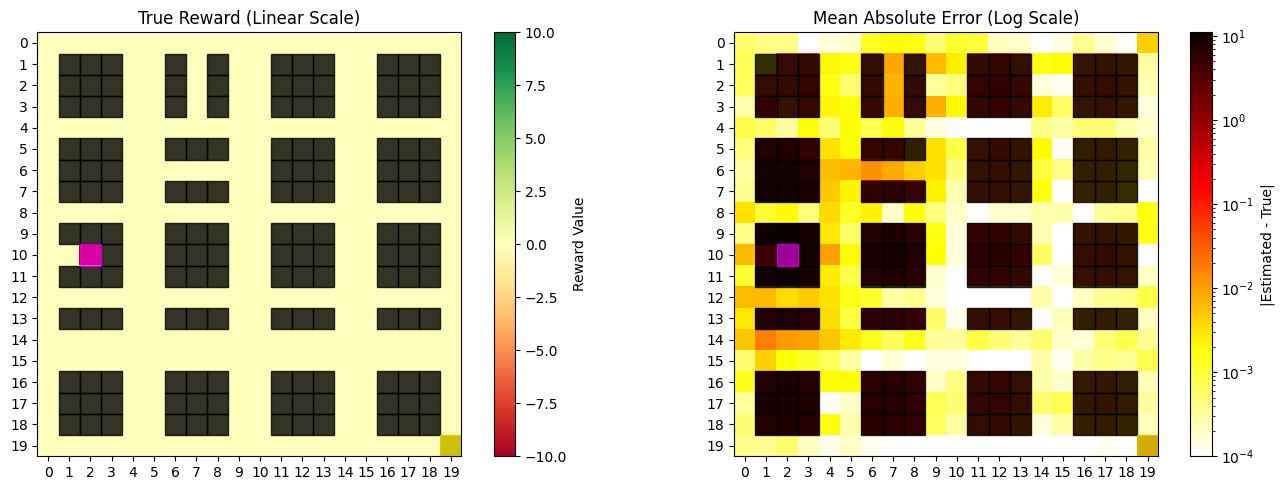

In [134]:
solver_macro = FOGASSolverVectorized(
    mdp      = mdp_macro,
    csv_path = str(MACRO_DATASET_PATH_100_20),
    device   = device,
    beta     = 1e-7,
    seed     = seed,
)
evaluator_macro = FOGASEvaluator(solver_macro)
optimizer_macro = FOGASHyperOptimizer(
    solver          = solver_macro,
    metric_callable = evaluator_macro.get_metric("reward"),
    seed            = seed,
)

evaluator_macro.analyze_reward_approximation(
    walls      = mdp_data_20["walls"],
    pits       = mdp_data_20["pits"],
    goal       = mdp_data_20["goal"],
    print_each = True,
)

In [135]:
solver_macro.run(
    alpha=0.0001,
    eta=0.00002,
    rho=0.5,
    tqdm_print=True,
    T=20000
)

evaluator_macro.print_optimal_path(goal_state=mdp_data_20["goal"], show_value_info=False)

FOGAS: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20000/20000 [00:44<00:00, 447.02it/s]


  OPTIMAL PATH VISUALIZATION - Learned Policy (π_FOGAS)

Initial State: 0
Goal State: 399
Discount Factor (γ): 0.99

----------------------------------------------------------------------

  Step   0 │ State: 0        │ Action: 1       │ Reward:  -0.045 │ → 20
  Step   1 │ State: 20       │ Action: 1       │ Reward:  -0.045 │ → 40
  Step   2 │ State: 40       │ Action: 1       │ Reward:  -0.045 │ → 60
  Step   3 │ State: 60       │ Action: 1       │ Reward:  -0.045 │ → 80
  Step   4 │ State: 80       │ Action: 1       │ Reward:  -0.045 │ → 100
  Step   5 │ State: 100      │ Action: 1       │ Reward:  -0.045 │ → 120
  Step   6 │ State: 120      │ Action: 1       │ Reward:  -0.045 │ → 140
  Step   7 │ State: 140      │ Action: 1       │ Reward:  -0.045 │ → 160
  Step   8 │ State: 160      │ Action: 1       │ Reward:  -0.045 │ → 180
  Step   9 │ State: 180      │ Action: 1       │ Reward:  -0.045 │ → 200
  Step  10 │ State: 200      │ Action: 1       │ Reward:  -0.045 │ → 220
  Step  11 

In [136]:
evaluator_macro.print_policy()

  State 0: π(a=0|s=0) = 0.11  π(a=1|s=0) = 0.46  π(a=2|s=0) = 0.09  π(a=3|s=0) = 0.34  --> best action: 1
  State 1: π(a=0|s=1) = 0.04  π(a=1|s=1) = 0.22  π(a=2|s=1) = 0.01  π(a=3|s=1) = 0.74  --> best action: 3
  State 2: π(a=0|s=2) = 0.07  π(a=1|s=2) = 0.24  π(a=2|s=2) = 0.01  π(a=3|s=2) = 0.67  --> best action: 3
  State 3: π(a=0|s=3) = 0.14  π(a=1|s=3) = 0.36  π(a=2|s=3) = 0.05  π(a=3|s=3) = 0.45  --> best action: 3
  State 4: π(a=0|s=4) = 0.07  π(a=1|s=4) = 0.32  π(a=2|s=4) = 0.03  π(a=3|s=4) = 0.58  --> best action: 3
  State 5: π(a=0|s=5) = 0.07  π(a=1|s=5) = 0.28  π(a=2|s=5) = 0.02  π(a=3|s=5) = 0.63  --> best action: 3
  State 6: π(a=0|s=6) = 0.16  π(a=1|s=6) = 0.32  π(a=2|s=6) = 0.04  π(a=3|s=6) = 0.49  --> best action: 3
  State 7: π(a=0|s=7) = 0.14  π(a=1|s=7) = 0.27  π(a=2|s=7) = 0.06  π(a=3|s=7) = 0.53  --> best action: 3
  State 8: π(a=0|s=8) = 0.08  π(a=1|s=8) = 0.21  π(a=2|s=8) = 0.05  π(a=3|s=8) = 0.66  --> best action: 3
  State 9: π(a=0|s=9) = 0.10  π(a=1|s=9) = 0.2

### Solve policy


In [142]:
def fine_to_coarse_state_100_20(x_fine, fine_size=100, coarse_size=20, factor=5):
    """Map a 100×100 fine-grid state index to its 20×20 coarse-grid cell."""
    r_f, c_f = divmod(int(x_fine), fine_size)
    r_c, c_c = r_f // factor, c_f // factor
    return int(r_c * coarse_size + c_c)

In [143]:
# ─────────────────────────────────────────────────────────────────────────────
# Rollout function: apply macro policy on the fine MDP (LinearMDP version)
# ─────────────────────────────────────────────────────────────────────────────
def rollout_macro_policy_on_fine_mdp_100(
    pi_macro,                       # (S_coarse, A) array or tensor
    mdp_fine,                       # LinearMDP for 100×100
    mdp_data_fine,                  # dict with start, goal, pits, ...
    fine_to_coarse_state_fn,        # function(x_fine) → x_coarse
    macro_factor=5,                 # fine steps per macro step
    max_macro_steps=200,
    deterministic=True,
):
    """
    Roll out a coarse (20×20) macro policy on the fine (100×100) MDP.
    One macro step:
      1. map fine state x_t → coarse state g(x_t)
      2. choose macro action a ~ pi_macro[g(x_t)]
      3. apply the SAME fine action `macro_factor` times in the fine MDP
    """
    if isinstance(pi_macro, torch.Tensor):
        pi_macro_np = pi_macro.detach().cpu().numpy()
    else:
        pi_macro_np = np.asarray(pi_macro)
    x = int(mdp_data_fine["start"])
    path      = [x]
    actions   = []
    rewards   = []
    transitions = []
    goal = int(mdp_data_fine["goal"])
    pits = {int(p) for p in mdp_data_fine["pits"]}
    gamma_fine = float(mdp_fine.gamma)   # LinearMDP stores gamma as a scalar tensor or float
    for _ in range(max_macro_steps):
        x_coarse = int(fine_to_coarse_state_fn(x))
        # ── pick macro action ──────────────────────────────────────────────
        if deterministic:
            a = int(np.argmax(pi_macro_np[x_coarse]))
        else:
            a = int(np.random.choice(pi_macro_np.shape[1],
                                     p=pi_macro_np[x_coarse]))
        # ── apply the same action `macro_factor` times ────────────────────
        macro_reward = 0.0
        x_curr = x
        for k in range(macro_factor):
            row_idx = x_curr * mdp_fine.A + a   # LinearMDP: P is (S*A, S)
            if deterministic:
                x_next = int(torch.argmax(mdp_fine.P[row_idx]).item())
            else:
                probs  = mdp_fine.P[row_idx]
                x_next = int(torch.multinomial(probs, num_samples=1).item())
            r = float(mdp_fine.r[row_idx].item())
            macro_reward += (gamma_fine ** k) * r
            path.append(x_next)
            transitions.append((x_curr, a, r, x_next))
            x_curr = x_next
        actions.append(a)
        rewards.append(macro_reward)
        x = x_curr
        if x == goal or x in pits:
            break
    return {
        "path":         path,
        "actions":      actions,
        "macro_rewards": rewards,
        "transitions":  transitions,
    }

Macro rollout: 400 macro steps, 2001 fine-grid states visited
Reached goal: False
Total macro reward: -18.133


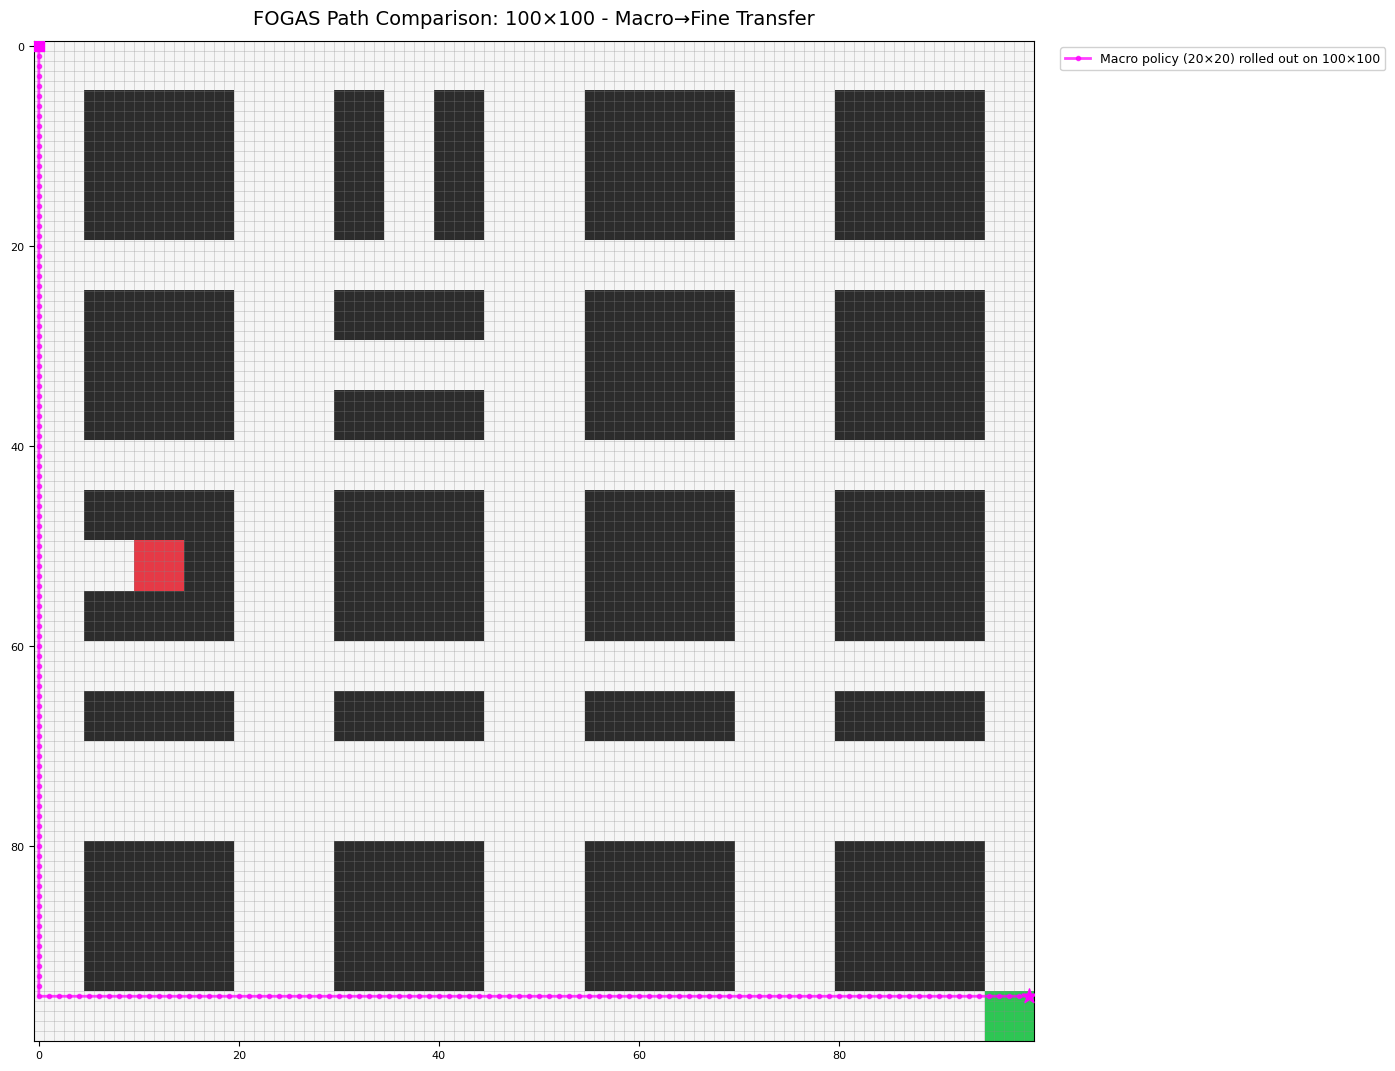

In [146]:
# ─────────────────────────────────────────────────────────────────────────────
# Run the rollout
# ─────────────────────────────────────────────────────────────────────────────
macro_rollout_100 = rollout_macro_policy_on_fine_mdp_100(
    pi_macro                = solver_macro.pi,          # ← was pi_star, correct attr is .pi
    mdp_fine                = mdp_100,
    mdp_data_fine           = mdp_data_100,
    fine_to_coarse_state_fn = fine_to_coarse_state_100_20,
    macro_factor            = MACRO_FACTOR,
    max_macro_steps         = 400,
    deterministic           = True,
)

# ── Summary ───────────────────────────────────────────────────────────────────
macro_path_100 = [divmod(s, size_100) for s in macro_rollout_100["path"]]

print(f"Macro rollout: {len(macro_rollout_100['actions'])} macro steps, "
      f"{len(macro_rollout_100['path'])} fine-grid states visited")
print(f"Reached goal: {macro_rollout_100['path'][-1] == goal_100}")
print(f"Total macro reward: {sum(macro_rollout_100['macro_rewards']):.3f}")

# ─────────────────────────────────────────────────────────────────────────────
# Plot
# ─────────────────────────────────────────────────────────────────────────────
plot_agent_paths_with_labels(
    scale_grid_goal_block(grid_20, factor=5),                                            # ← numpy grid array, not mdp_data_100["grid"]
    [macro_path_100],
    labels=["Macro policy (20×20) rolled out on 100×100"],
    title_suffix="- Macro→Fine Transfer",
)
